Data Cleaning - Titanic Dataset
The objective of this project is to demonstrate professional data cleaning techniques by transforming a raw Titanic dataset into a clean and analysis-ready dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("Number of rows and columns:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Number of rows and columns: (891, 12)

Column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
#Data Quality Report

quality_report = pd.DataFrame({
    'Column': df.columns,
    'Missing Values': df.isnull().sum().values,
    'Missing Percentage':(df.isnull().sum().values/len(df)* 100).round(2),
    'Data Type': df.dtypes.values,
    'Unique Values':  df.nunique().values
})

quality_report

,Column,Missing Values,Missing Percentage,Data Type,Unique Values
0,PassengerId,0,0.00,int64,891
1,Survived,0,0.00,int64,2
2,Pclass,0,0.00,int64,3
3,Name,0,0.00,object,891
4,Sex,0,0.00,object,2
5,Age,177,19.87,float64,88
6,SibSp,0,0.00,int64,7
7,Parch,0,0.00,int64,7
8,Ticket,0,0.00,object,681
9,Fare,0,0.00,float64,248


In [5]:
#Missing Values
print("Missing values per column:")
print(df.isnull().sum())

#Duplicate Rows
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

#Data types
print("\nData types:")
print(df.dtypes)

#Numerical summary for checking value ranges
print("\nNumerical value ranges:")
print(df.describe().T[['min', 'max']])

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Number of duplicate rows:
0

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Numerical value ranges:
              min       max
PassengerId  1.00  891.0000
Survived     0.00    1.0000
Pclass       1.00    3.0000
Age          0.42   80.0000
SibSp        0.00    8.0000
Parch        0.00    6.0000
Fare         0.00  512.3292


The initial quality evaluation shows that the dataset contains missing values in the 'Age','Cabin',and 'Embarked' columns. The 'Cabin' column has the highest number of missing values at 77.10%, then 'Age' at 19.87%. The 'Embarked' column has only 0.22% missing values.
Also no duplicate rows were found in the dataset.  

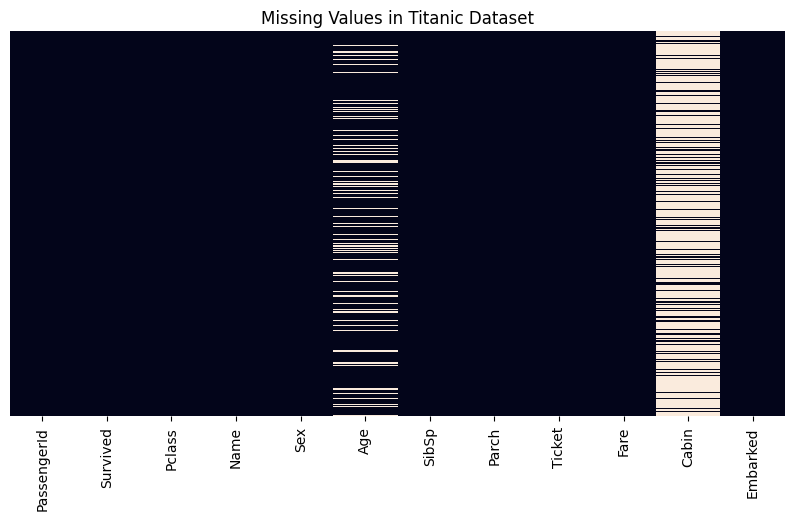

In [6]:
#Visualize missing values

plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title('Missing Values in Titanic Dataset')
plt.show()

In [7]:
#Display missing value counts
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

print("Columns with missing values:")
print(missing_values)

Columns with missing values:
Age         177
Cabin       687
Embarked      2
dtype: int64


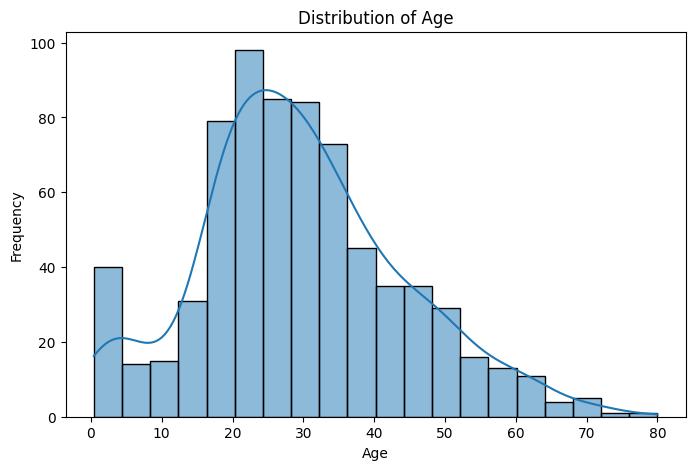

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'].dropna(), kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [9]:
print("Mean Age:", df['Age'].mean())
print("Median Age:", df['Age'].median())

Mean Age: 29.69911764705882
Median Age: 28.0


#Handling Missing Values in Age
The Age column contains 177 missig values. The distribution of age is slightly right-skewed, with a mean of 29.70(approx) and a median of 28.00. Since the median is less sensitive to extreme values, the missing 'Age' values will be replaced with the median age.

In [10]:
df['Age'] = df['Age'].fillna(df['Age'].median())
print("Missing values in Age after imputation:", df['Age'].isnull().sum())

Missing values in Age after imputation: 0


In [11]:
print("Number of unique Cabin values:", df['Cabin'].nunique())

print("\nSample Cabin values:")
print(df['Cabin'].dropna().head(10))

Number of unique Cabin values: 147

Sample Cabin values:
1             C85
3            C123
6             E46
10             G6
11           C103
21            D56
23             A6
27    C23 C25 C27
31            B78
52            D33
Name: Cabin, dtype: object


#Handling Missing Value in Cabin
The 'Cabin' column contains 687 missing values out of 891 values, showing 77.10% of the dataset.Since most cabin values are unavailable, imputing specific cabin numbers would introduce unreliable information.
A new binary feature, 'Cabin_Available', will be created to indicate whether cabin information is available. The original 'Cabin' column will be removed due to missing values.

In [12]:
df['Cabin_Available']= df['Cabin'].notna().astype(int)
print(df['Cabin_Available'].value_counts())

Cabin_Available
0    687
1    204
Name: count, dtype: int64


In [13]:
df.drop('Cabin', axis=1, inplace=True)

print("Cabin column removed.")
print("Remaining columns:")
print(df.columns.tolist())

Cabin column removed.
Remaining columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked', 'Cabin_Available']


In [14]:
print("Missing values after handling Cabin:")
print(df.isnull().sum())

Missing values after handling Cabin:
PassengerId        0
Survived           0
Pclass             0
Name               0
Sex                0
Age                0
SibSp              0
Parch              0
Ticket             0
Fare               0
Embarked           2
Cabin_Available    0
dtype: int64


In [15]:
print("Embarked value counts:")
print(df['Embarked'].value_counts())

Embarked value counts:
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


# Handling Missing Values in Embarked

The `Embarked` column contains only 2 missing values. Since it is a categorical column and `S` is the most frequent category, the missing values will be replaced with the mode of 'S'.

In [16]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
print("Missing values in Embarked after imputation:", df['Embarked'].isnull().sum())

Missing values in Embarked after imputation: 0


#Duplicate Records
There were no duplicate records in the dataset.So, no rows were removed.

In [17]:
#Check and remove Duplicate rows
duplicates_before = df.duplicated().sum()

df = df.drop_duplicates()

duplicates_after = df.duplicated().sum()

print("Duplicate rows before cleaning:", duplicates_before)
print("Duplicate rows after cleaning:", duplicates_after)

Duplicate rows before cleaning: 0
Duplicate rows after cleaning: 0


In [18]:
#Check unique values in categorical columns

print("Sex values:")
print(df['Sex'].unique())

print("\nEmbarked values:")
print(df['Embarked'].unique())

Sex values:
['male' 'female']

Embarked values:
['S' 'C' 'Q']


#Standardization of Categorical Data
The categorical columns were inspected for inconsistent formatting.The 'Sex' column contains only 'male' and 'female', while the 'Embarked' column contains only 'S', 'C', and 'Q'.
No inconsistent categorical values were found, so no standardization was required for these columns.

### Date Format Check

The dataset does not contain any date or datetime columns. Therefore, no date-format standardization was required.

In [19]:
#Detect outliers using the IQR method

numerical_columns = ['Age', 'Fare']
outlier_summary = []

for column in numerical_columns:
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR =Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

  outlier_summary.append({
      'Column': column,
      'Q1': Q1,
      'Q3': Q3,
      'IQR': IQR,
      'Lower Bound': lower_bound,
      'Upper Bound': upper_bound,
      'Number of Outliers': len(outliers)
  })

outlier_summary_df = pd.DataFrame(outlier_summary)

outlier_summary_df

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Number of Outliers
0,Age,22.0000,35.0,13.0000,2.500,54.5000,66
1,Fare,7.9104,31.0,23.0896,-26.724,65.6344,116


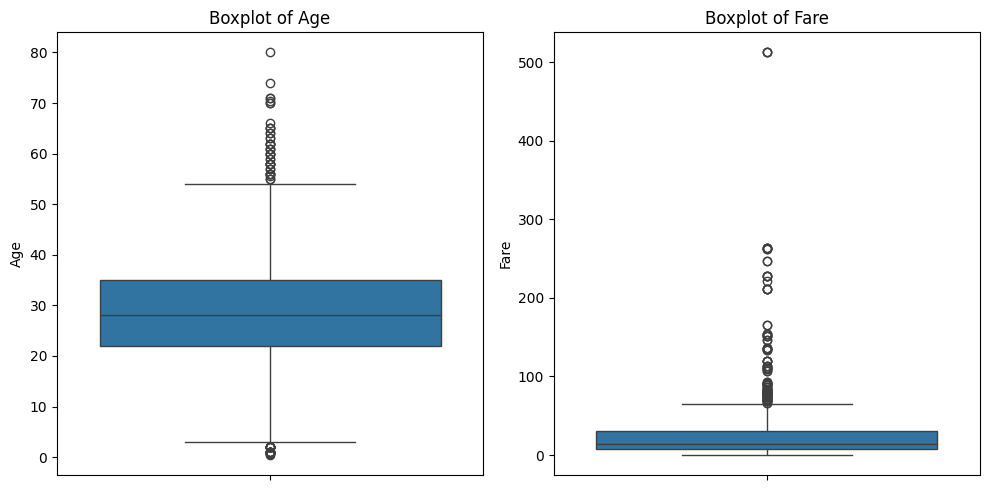

In [20]:
#Visualize outliers using boxplots
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['Age'])
plt.title('Boxplot of Age')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Fare'])
plt.title('Boxplot of Fare')

plt.tight_layout()
plt.show()

#Outlier Treatment
The IQR method identified 66 outliers in 'Age' and 116 outliers in 'Fare'. These observations were reviewed using their valid numerical ranges and boxplots.
The detected values appear to represent legitimate passenger ages and ticket fares rather than data-entry errors. Therefore, the outliers will be retained instead of being removed or capped, to avoid losing potentially meaningful information from the dataset.


In [21]:
print("Maximum Age:", df['Age'].max())
print("Maximum Fare:", df['Fare'].max())

Maximum Age: 80.0
Maximum Fare: 512.3292


In [22]:
# Check current data types

print("Current data types:")
print(df.dtypes)

Current data types:
PassengerId          int64
Survived             int64
Pclass               int64
Name                object
Sex                 object
Age                float64
SibSp                int64
Parch                int64
Ticket              object
Fare               float64
Embarked            object
Cabin_Available      int64
dtype: object


#Data Type Verification
All columns were reviewed to ensure that their data types are appropriate for analysis. The numerical,categorical, and binary colums have suitable data types, so no further data type correction was required.

In [23]:
#Current data quality after cleaning

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Total missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Data types:")
print(df.dtypes)

Rows: 891
Columns: 12
Total missing values: 0
Duplicate rows: 0
Data types:
PassengerId          int64
Survived             int64
Pclass               int64
Name                object
Sex                 object
Age                float64
SibSp                int64
Parch                int64
Ticket              object
Fare               float64
Embarked            object
Cabin_Available      int64
dtype: object


#Before vs. After Data Quality Summary
The following table compares the dataset before and after the cleaning process. The cleaning process handled all missing values, checked duplicate records, verified data types, and retained valid statistical outliers.

In [24]:
#Before vs. After Data Quality Summary

before_after = pd.DataFrame({
    'Metric': [
        'Rows',
        'Columns',
        'Total Missing Values',
        'Duplicate Rows',
    ],
    'Before Cleaning': [
        891,
        12,
        866,
        0
    ],
    'After Cleaning': [
        len(df),
        len(df.columns),
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ]
})
before_after

,Metric,Before Cleaning,After Cleaning
0,Rows,891,891
1,Columns,12,12
2,Total Missing Values,866,0
3,Duplicate Rows,0,0


# Data Type Accuracy

The data types were reviewed before and after cleaning. All columns have appropriate data types for analysis, and no data type correction was required.

In [25]:
#Save the cleaned dataset
df.to_csv('titanic_cleaned.csv', index=False)

print("Cleaned dataset saved successfully as 'titanic_cleaned.csv'")

Cleaned dataset saved successfully as 'titanic_cleaned.csv'


In [26]:
#Final verification
cleaned_df = pd.read_csv('titanic_cleaned.csv')

print("Final dataset shape:", cleaned_df.shape)
print("Total missing values:", cleaned_df.isnull().sum().sum())
print("Total duplicate rows:", cleaned_df.duplicated().sum())

Final dataset shape: (891, 12)
Total missing values: 0
Total duplicate rows: 0


#Conclusion
## Conclusion

The Titanic dataset was successfully cleaned and prepared for analysis. Missing values in 'Age', 'Cabin', and 'Embarked' were handled using appropriate strategies. Duplicate records were checked and none were found. Categorical values and data types were verified, and numerical outliers were identified using the IQR method and retained because they appeared to represent valid observations.

The cleaned dataset contains 891 rows, 12 columns, no missing values, and no duplicate records. The final dataset was saved as 'titanic_cleaned.csv' and is ready for further analysis.